In [63]:
from networkSim.utils.netStat import net_episode_generator
import matplotlib.pyplot as plt
from networkSim.utils.shaping import BILIBILI_TRANSITIONS, YOUTUBE_TRANSITIONS, TWITCH_TRANSITIONS, TIKTOK_TRANSITIONS


In [64]:
datas = []
for i,item in enumerate(net_episode_generator(episode_length= 120,transition_dict= TIKTOK_TRANSITIONS)):
    datas.append(item)
    if i == 50:
        break

In [65]:
total_duration = sum(item.duration for item in datas)
print(total_duration)

1845.3667717407775


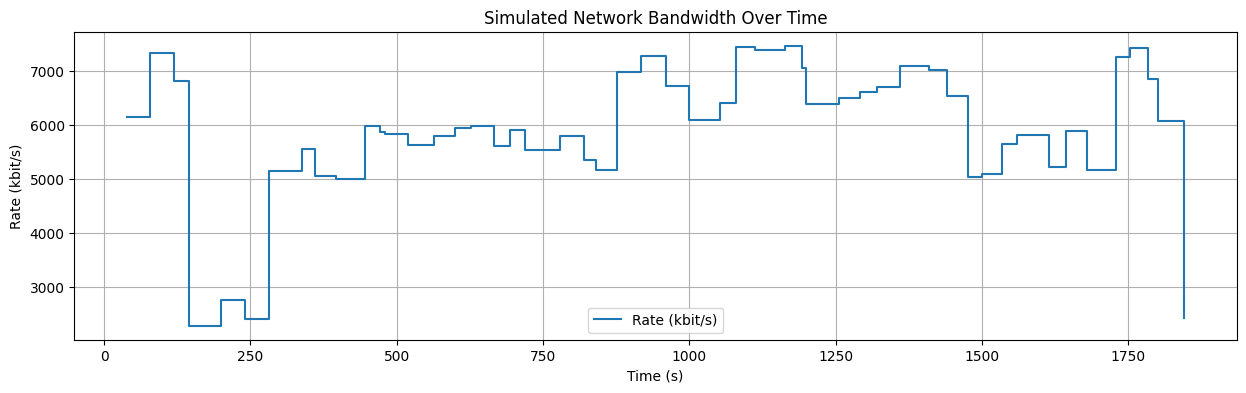

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Prepare time series
times = [0]  # cumulative time
rates = [datas[0].rate]
states = []  # store resolution for color coding



for item in datas:
    states.append(item.state)
    # append next cumulative time
    times.append(times[-1] + item.duration)
    rates.append(item.rate)

# remove first dummy entry
times = times[1:]
rates = rates[1:]

# 2️⃣ Plot rate over time
plt.figure(figsize=(15,4))
plt.step(times, rates, where='post', label="Rate (kbit/s)")
plt.xlabel("Time (s)")
plt.ylabel("Rate (kbit/s)")
plt.title("Simulated Network Bandwidth Over Time")
plt.grid(True)
plt.legend()
plt.show()

# 3️⃣ Optional: color by state
state_colors = {
    "10": "#00cc00",  # strong green (best)
    "9":  "#66ff33",  # lime green
    "8":  "#ccff33",  # yellow-green
    "7":  "#ffff00",  # yellow
    "6":  "#ffcc00",  # amber
    "5":  "#ff9900",  # orange
    "4":  "#ff4d00",  # deep orange-red
    "3":  "#ff1a1a",  # red
    "2":  "#cc0000",  # dark red
    "1":  "#660000",  # very dark red (worst)
}

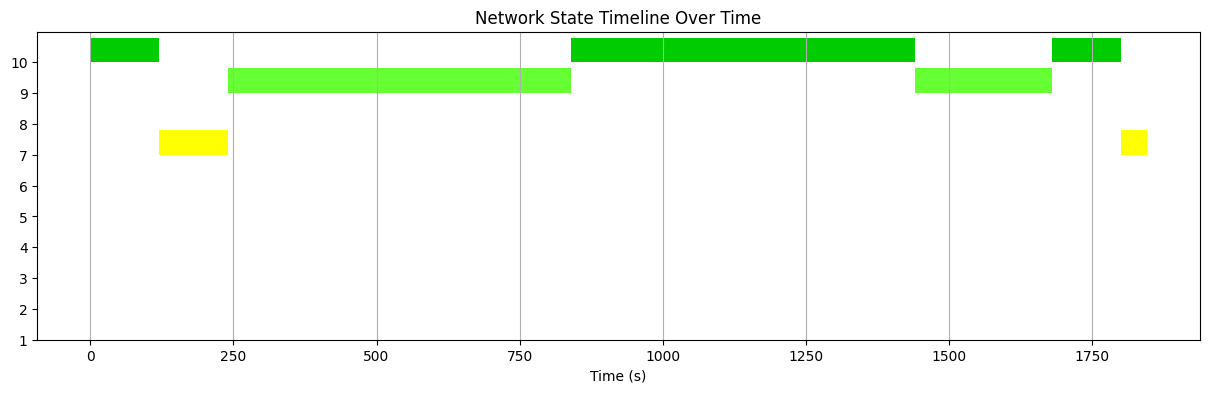

In [67]:
import matplotlib.pyplot as plt



# Prepare data for broken_barh
bars = []
state_y = {
    "10": 90,
    "9": 80,
    "8": 70,
    "7": 60,
    "6": 50,
    "5": 40,
    "4": 30,
    "3": 20,
    "2": 10,
    "1": 0,
}

cumulative_time = 0
for item in datas:
    state = item.state
    bars.append(
        (cumulative_time, item.duration, state)
    )
    cumulative_time += item.duration

# Plot
plt.figure(figsize=(15,4))
for start, duration, state in bars:
    plt.broken_barh(
        [(start, duration)],  # x = (start, width)
        (state_y[state], 8),  # y = (bottom, height)
        facecolors=state_colors[state]
    )

plt.yticks([0, 10, 20, 30, 40, 50, 60, 70,80,90], ["1", "2", "3", "4","5", "6", "7", "8", "9", "10"])
plt.xlabel("Time (s)")
plt.title("Network State Timeline Over Time")
plt.grid(True, axis='x')
plt.show()